In [33]:
# Cell 1: Import libraries dan setup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [34]:
data = pd.read_csv("./generated_data.csv")

df = pd.DataFrame(data)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nStatistical summary:")
print(df.describe())

Dataset shape: (3000, 8)

First 5 rows:
   tinggi_badan_cm  umur_tahun  batuk_lama  demam  keringat_malam  \
0              200          44       False   True           False   
1              144          84        True  False            True   
2              187          21        True   True           False   
3              141          80        True   True           False   
4              158          42        True   True           False   

   penurunan_berat_badan  skor_risiko_tb  rekomendasi_pemeriksaan_dokter  
0                   True        0.770147                            True  
1                   True        0.487874                            True  
2                  False        0.351154                           False  
3                   True        0.815886                           False  
4                  False        0.750505                           False  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data c

In [35]:
# Cell 3: Preprocessing
# Convert boolean to numeric (0 and 1)
df['batuk_lama'] = df['batuk_lama'].astype(int)
df['demam'] = df['demam'].astype(int)
df['keringat_malam'] = df['keringat_malam'].astype(int)
df['penurunan_berat_badan'] = df['penurunan_berat_badan'].astype(int)

df = df.drop('rekomendasi_pemeriksaan_dokter', axis=1)

# Separate features (X) and target (y)
X = df.drop('skor_risiko_tb', axis=1)
y = df['skor_risiko_tb']

print("Features (X):")
print(X.head())
print(f"\nTarget (y) - skor_risiko_tb:")
print(y.head())
print(f"\nFeature columns: {list(X.columns)}")

Features (X):
   tinggi_badan_cm  umur_tahun  batuk_lama  demam  keringat_malam  \
0              200          44           0      1               0   
1              144          84           1      0               1   
2              187          21           1      1               0   
3              141          80           1      1               0   
4              158          42           1      1               0   

   penurunan_berat_badan  
0                      1  
1                      1  
2                      0  
3                      1  
4                      0  

Target (y) - skor_risiko_tb:
0    0.770147
1    0.487874
2    0.351154
3    0.815886
4    0.750505
Name: skor_risiko_tb, dtype: float64

Feature columns: ['tinggi_badan_cm', 'umur_tahun', 'batuk_lama', 'demam', 'keringat_malam', 'penurunan_berat_badan']


In [36]:
# Cell 4: Split data dan normalisasi
# Split into train and test sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (penting untuk model linear)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nFeature scaling completed!")

Training set size: 2400 samples
Test set size: 600 samples

Feature scaling completed!


In [37]:
# Cell 5: Train multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    # Train (Linear Regression perlu data scaled, tree-based tidak)
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': y_pred
    }
    
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

# Find best model
best_model_name = min(results, key=lambda x: results[x]['rmse'])
print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model_name}")
print(f"RMSE: {results[best_model_name]['rmse']:.4f}")
print(f"R² Score: {results[best_model_name]['r2']:.4f}")
print('='*50)


Training Linear Regression...
Mean Squared Error (MSE): 0.0842
Root Mean Squared Error (RMSE): 0.2902
Mean Absolute Error (MAE): 0.2523
R² Score: -0.0007

Training Random Forest...
Mean Squared Error (MSE): 0.0842
Root Mean Squared Error (RMSE): 0.2902
Mean Absolute Error (MAE): 0.2518
R² Score: -0.0010

Training Gradient Boosting...
Mean Squared Error (MSE): 0.0852
Root Mean Squared Error (RMSE): 0.2919
Mean Absolute Error (MAE): 0.2516
R² Score: -0.0124

BEST MODEL: Linear Regression
RMSE: 0.2902
R² Score: -0.0007



Random Forest - Feature Importance:
                 feature  importance
1             umur_tahun    0.436297
0        tinggi_badan_cm    0.389206
4         keringat_malam    0.054896
2             batuk_lama    0.043432
5  penurunan_berat_badan    0.041496
3                  demam    0.034672


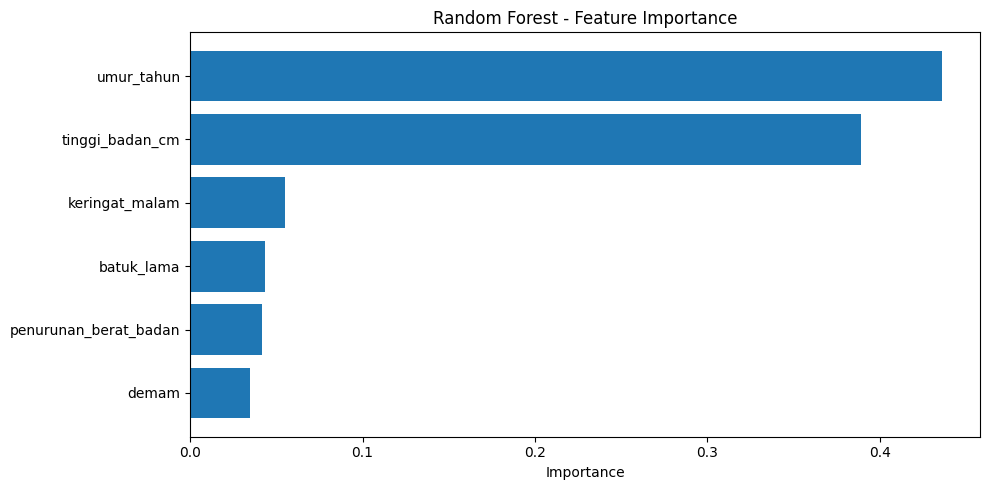


Gradient Boosting - Feature Importance:
                 feature  importance
1             umur_tahun    0.420187
0        tinggi_badan_cm    0.385570
4         keringat_malam    0.077966
2             batuk_lama    0.048983
3                  demam    0.042293
5  penurunan_berat_badan    0.025001


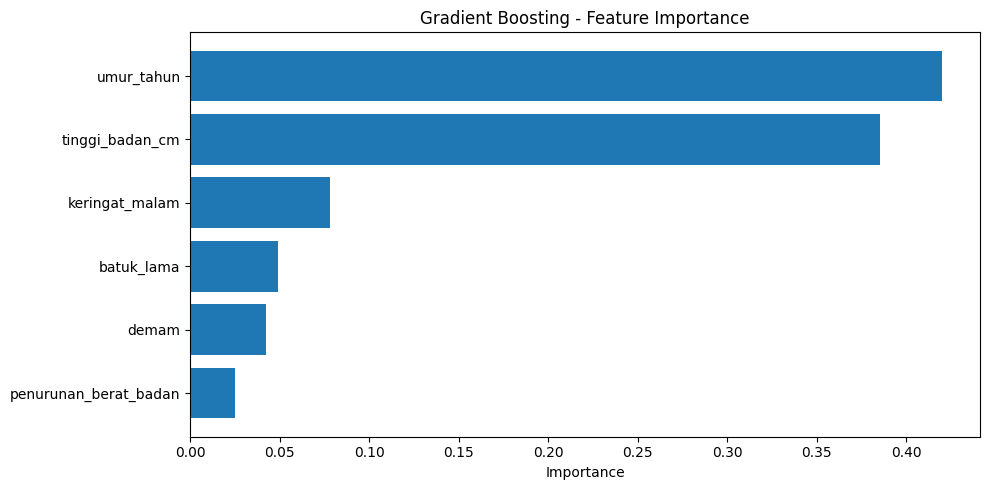

In [38]:
# Cell 6: Feature importance (untuk Random Forest dan Gradient Boosting)
import matplotlib.pyplot as plt

for name in ['Random Forest', 'Gradient Boosting']:
    model = results[name]['model']
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n{name} - Feature Importance:")
    print(feature_importance)
    
    plt.figure(figsize=(10, 5))
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Importance')
    plt.title(f'{name} - Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [39]:
# Cell 7: Save best model
best_model = results[best_model_name]['model']

# Save model dan scaler
joblib.dump(best_model, 'tb_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"✓ Model saved: tb_risk_model.pkl")
print(f"✓ Scaler saved: scaler.pkl")
print(f"\nBest model: {best_model_name}")

✓ Model saved: tb_risk_model.pkl
✓ Scaler saved: scaler.pkl

Best model: Linear Regression


In [40]:
# Cell 8: Fungsi prediksi untuk deployment
def predict_tb_risk(tinggi_badan_cm, umur_tahun, batuk_lama, demam, 
                    keringat_malam, penurunan_berat_badan):
    """
    Prediksi skor risiko TB berdasarkan gejala pasien
    
    Parameters:
    - tinggi_badan_cm: int (cm)
    - umur_tahun: int (tahun)
    - batuk_lama: bool (True/False)
    - demam: bool (True/False)
    - keringat_malam: bool (True/False)
    - penurunan_berat_badan: bool (True/False)
    
    Returns:
    - skor_risiko: float (0-1)
    - kategori: str ('Low Risk', 'Medium Risk', 'High Risk')
    - rekomendasi: bool (perlu pemeriksaan dokter)
    """
    # Load model
    model = joblib.load('tb_risk_model.pkl')
    scaler = joblib.load('scaler.pkl')
    
    # Prepare input
    input_data = pd.DataFrame({
        'tinggi_badan_cm': [tinggi_badan_cm],
        'umur_tahun': [umur_tahun],
        'batuk_lama': [int(batuk_lama)],
        'demam': [int(demam)],
        'keringat_malam': [int(keringat_malam)],
        'penurunan_berat_badan': [int(penurunan_berat_badan)],
    })
    
    # Predict
    if best_model_name == 'Linear Regression':
        input_scaled = scaler.transform(input_data)
        skor_risiko = model.predict(input_scaled)[0]
    else:
        skor_risiko = model.predict(input_data)[0]
    
    # Clip to [0, 1] range
    skor_risiko = np.clip(skor_risiko, 0, 1)
    
    # Kategorisasi
    if skor_risiko < 0.4:
        kategori = 'Low Risk'
        rekomendasi = False
    elif skor_risiko < 0.7:
        kategori = 'Medium Risk'
        rekomendasi = True
    else:
        kategori = 'High Risk'
        rekomendasi = True
    
    return {
        'skor_risiko_tb': round(skor_risiko, 4),
        'kategori': kategori,
        'rekomendasi_pemeriksaan_dokter': rekomendasi
    }

print("✓ Fungsi prediksi siap digunakan!")

✓ Fungsi prediksi siap digunakan!


In [41]:
# Cell 9: Test prediksi dengan data contoh Anda
print("Testing dengan data sample Anda:")
print("="*60)

test_case = {
    'tinggi_badan_cm': 200,
    'umur_tahun': 44,
    'batuk_lama': False,
    'demam': True,
    'keringat_malam': False,
    'penurunan_berat_badan': True
}

result = predict_tb_risk(**test_case)

print(f"Input:")
for key, value in test_case.items():
    print(f"  {key}: {value}")

print(f"\nHasil Prediksi:")
print(f"  Skor Risiko TB: {result['skor_risiko_tb']:.4f}")
print(f"  Kategori: {result['kategori']}")
print(f"  Rekomendasi Pemeriksaan Dokter: {result['rekomendasi_pemeriksaan_dokter']}")

print("\n" + "="*60)
print("Testing dengan beberapa kasus lain:")
print("="*60)

# Test case 2: Low risk
print("\nCase 2 - Low Risk (tidak ada gejala berat):")
result2 = predict_tb_risk(170, 30, False, False, False, False)
print(f"  Skor: {result2['skor_risiko_tb']:.4f} | Kategori: {result2['kategori']}")

# Test case 3: High risk
print("\nCase 3 - High Risk (semua gejala):")
result3 = predict_tb_risk(165, 55, True, True, True, True)
print(f"  Skor: {result3['skor_risiko_tb']:.4f} | Kategori: {result3['kategori']}")

# Test case 4: Medium risk
print("\nCase 4 - Medium Risk (beberapa gejala):")
result4 = predict_tb_risk(175, 40, True, False, True, False)
print(f"  Skor: {result4['skor_risiko_tb']:.4f} | Kategori: {result4['kategori']}")

Testing dengan data sample Anda:
Input:
  tinggi_badan_cm: 200
  umur_tahun: 44
  batuk_lama: False
  demam: True
  keringat_malam: False
  penurunan_berat_badan: True

Hasil Prediksi:
  Skor Risiko TB: 0.4919
  Kategori: Medium Risk
  Rekomendasi Pemeriksaan Dokter: True

Testing dengan beberapa kasus lain:

Case 2 - Low Risk (tidak ada gejala berat):
  Skor: 0.4941 | Kategori: Medium Risk

Case 3 - High Risk (semua gejala):
  Skor: 0.4959 | Kategori: Medium Risk

Case 4 - Medium Risk (beberapa gejala):
  Skor: 0.4981 | Kategori: Medium Risk


In [42]:
# Cell 10: Summary dan next steps
print("""
═══════════════════════════════════════════════════════════════
                    MODEL SUMMARY
═══════════════════════════════════════════════════════════════

✓ Model Type: Regression (Classical ML - NOT Deep Learning)
✓ Algorithms Tested: Linear Regression, Random Forest, Gradient Boosting
✓ Best Model Saved: tb_risk_model.pkl
✓ Scaler Saved: scaler.pkl

INPUT FEATURES:
  1. tinggi_badan_cm (numeric)
  2. umur_tahun (numeric)
  3. batuk_lama (boolean → 0/1)
  4. demam (boolean → 0/1)
  5. keringat_malam (boolean → 0/1)
  6. penurunan_berat_badan (boolean → 0/1)

OUTPUT:
  - skor_risiko_tb: float (0-1)
  - kategori: Low Risk (<0.4) | Medium Risk (0.4-0.7) | High Risk (>0.7)
  - rekomendasi_pemeriksaan_dokter: boolean

NEXT STEPS:
  1. Ganti dataset sample dengan data REAL dari klinik/RS Anda
     (minimal 100-1000 data untuk akurasi baik)
  2. Re-train model dengan data real
  3. Integrate fungsi predict_tb_risk() ke backend NestJS Anda
  4. Deploy model menggunakan Flask/FastAPI atau langsung di backend

UNTUK INTEGRASI KE BACKEND:
  - Install di backend: pip install pandas scikit-learn joblib
  - Copy file: tb_risk_model.pkl dan scaler.pkl
  - Import fungsi predict_tb_risk atau buat API endpoint

═══════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════
                    MODEL SUMMARY
═══════════════════════════════════════════════════════════════

✓ Model Type: Regression (Classical ML - NOT Deep Learning)
✓ Algorithms Tested: Linear Regression, Random Forest, Gradient Boosting
✓ Best Model Saved: tb_risk_model.pkl
✓ Scaler Saved: scaler.pkl

INPUT FEATURES:
  1. tinggi_badan_cm (numeric)
  2. umur_tahun (numeric)
  3. batuk_lama (boolean → 0/1)
  4. demam (boolean → 0/1)
  5. keringat_malam (boolean → 0/1)
  6. penurunan_berat_badan (boolean → 0/1)

OUTPUT:
  - skor_risiko_tb: float (0-1)
  - kategori: Low Risk (<0.4) | Medium Risk (0.4-0.7) | High Risk (>0.7)
  - rekomendasi_pemeriksaan_dokter: boolean

NEXT STEPS:
  1. Ganti dataset sample dengan data REAL dari klinik/RS Anda
     (minimal 100-1000 data untuk akurasi baik)
  2. Re-train model dengan data real
  3. Integrate fungsi predict_tb_risk() ke backend NestJS Anda
  4. Deploy model menggunakan Flask/FastAPI 